In [15]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"Monikagarg01","key":"KGAT_ae7384fbaa45e8459ab59f2c8e66f778"}'}

In [16]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.system('cp kaggle.json /root/.kaggle/')
os.system('chmod 600 /root/.kaggle/kaggle.json')
print("Kaggle setup done!")

Kaggle setup done!


In [17]:
os.system('kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset')
print("Download complete!")

Download complete!


In [18]:
import os
files_list = os.listdir('/content/')
print("Files in content folder:")
for f in files_list:
    print(f)

Files in content folder:
.config
kaggle (1).json
kaggle.json
the-fake-or-real-dataset.zip
sample_data


In [19]:
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
the-fake-or-real-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [20]:
import os
import json

# Create kaggle.json directly with correct credentials
kaggle_creds = {
    "username": "Monikagarg01",
    "key": "KGAT_ae7384fbaa45e8459ab59f2c8e66f778"
}

os.makedirs('/root/.kaggle', exist_ok=True)

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("Credentials written successfully!")

# Verify
with open('/root/.kaggle/kaggle.json', 'r') as f:
    print("Content:", f.read())

Credentials written successfully!
Content: {"username": "Monikagarg01", "key": "KGAT_ae7384fbaa45e8459ab59f2c8e66f778"}


In [21]:
!kaggle datasets download -d mohammedabdeldayem/the-fake-or-real-dataset

Dataset URL: https://www.kaggle.com/datasets/mohammedabdeldayem/the-fake-or-real-dataset
License(s): GNU Lesser General Public License 3.0
the-fake-or-real-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [22]:
!unzip /content/the-fake-or-real-dataset.zip -d /content/fake-or-real/

Streaming output truncated to the last 5000 lines.
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12954.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12955.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12956.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12957.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12958.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12959.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12961.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/recording12962.wav_norm_mono.wav  
  inflating: /content/fake-or-real/for-rerec/for-rerecorded/training/real/rec

In [23]:
import os

for root, dirs, files in os.walk('/content/fake-or-real/'):
    level = root.replace('/content/fake-or-real/', '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')

/
for-rerec/
  for-rerecorded/
    validation/
    training/
    testing/
for-norm/
  for-norm/
    validation/
    training/
    testing/
for-original/
  for-original/
    validation/
    training/
    testing/
for-2sec/
  for-2seconds/
    validation/
    training/
    testing/


In [24]:
import glob

real_train = glob.glob('/content/fake-or-real/for-norm/for-norm/training/real/*.wav')
fake_train = glob.glob('/content/fake-or-real/for-norm/for-norm/training/fake/*.wav')

real_test = glob.glob('/content/fake-or-real/for-norm/for-norm/testing/real/*.wav')
fake_test = glob.glob('/content/fake-or-real/for-norm/for-norm/testing/fake/*.wav')

real_val = glob.glob('/content/fake-or-real/for-norm/for-norm/validation/real/*.wav')
fake_val = glob.glob('/content/fake-or-real/for-norm/for-norm/validation/fake/*.wav')

print(f"Training   → Real: {len(real_train)}, Fake: {len(fake_train)}")
print(f"Testing    → Real: {len(real_test)},  Fake: {len(fake_test)}")
print(f"Validation → Real: {len(real_val)},  Fake: {len(fake_val)}")
print(f"\nTotal files: {len(real_train)+len(fake_train)+len(real_test)+len(fake_test)+len(real_val)+len(fake_val)}")

Training   → Real: 26941, Fake: 26927
Testing    → Real: 2264,  Fake: 2370
Validation → Real: 5400,  Fake: 5398

Total files: 69300


In [25]:
import IPython.display as ipd

print("▶ Playing REAL audio sample:")
ipd.display(ipd.Audio(real_train[0]))

print("▶ Playing FAKE audio sample:")
ipd.display(ipd.Audio(fake_train[0]))

▶ Playing REAL audio sample:


▶ Playing FAKE audio sample:


In [26]:
!pip install librosa scikit-learn xgboost matplotlib seaborn tqdm -q

In [27]:
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully! ✅")

All libraries loaded successfully! ✅


In [28]:
def extract_features(file_path, sr=16000, duration=4):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=duration)

        # pad if audio is shorter than 4 seconds
        target_length = sr * duration
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)))

        features = []

        # MFCCs - captures voice texture and tone
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        features.extend(np.mean(mfcc, axis=1))
        features.extend(np.std(mfcc, axis=1))

        # Chroma - captures pitch patterns
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        features.extend(np.mean(chroma, axis=1))

        # Spectral features - captures voice brightness
        features.append(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
        features.append(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)))
        features.append(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))

        # Zero crossing rate - captures how noisy the signal is
        features.append(np.mean(librosa.feature.zero_crossing_rate(y)))

        # RMS Energy - captures loudness
        features.append(np.mean(librosa.feature.rms(y=y)))

        return np.array(features)

    except Exception as e:
        return None

print("Feature extractor ready! ✅")

Feature extractor ready! ✅


In [34]:
X = []
y_labels = []

all_files = (
    [(f, 0) for f in real_train] +
    [(f, 1) for f in fake_train] +
    [(f, 0) for f in real_test] +
    [(f, 1) for f in fake_test] +
    [(f, 0) for f in real_val] +
    [(f, 1) for f in fake_val]
)

print(f"Total files to process: {len(all_files)}")
print("Starting feature extraction")

for file_path, label in tqdm(all_files):
    features = extract_features(file_path)
    if features is not None:
        X.append(features)
        y_labels.append(label)

X = np.array(X)
y_labels = np.array(y_labels)

print(f"\nDone! ✅")
print(f"Feature matrix shape: {X.shape}")
print(f"Total samples: {len(y_labels)}")

Total files to process: 69300
Starting feature extraction


100%|██████████| 69300/69300 [46:14<00:00, 24.98it/s]



Done! ✅
Feature matrix shape: (69300, 97)
Total samples: 69300


In [35]:
np.save('X_features.npy', X)
np.save('y_labels.npy', y_labels)

print("Saved!")

Saved!


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_labels, test_size=0.2, random_state=42, stratify=y_labels
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 55440
Testing samples: 13860


In [37]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train_scaled, y_train)

y_pred = xgb.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy: {acc*100:.2f}%")

Accuracy: 99.38%


In [38]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=['Real', 'Fake']))

              precision    recall  f1-score   support

        Real       1.00      0.99      0.99      6921
        Fake       0.99      1.00      0.99      6939

    accuracy                           0.99     13860
   macro avg       0.99      0.99      0.99     13860
weighted avg       0.99      0.99      0.99     13860



In [39]:
from sklearn.metrics import roc_curve
import numpy as np

y_scores = xgb.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_scores)
fnr = 1 - tpr

eer_index = np.argmin(np.abs(fnr - fpr))
eer = fpr[eer_index]

print(f"Equal Error Rate (EER): {eer*100:.2f}%")
print(f"Target was: less than 12%")

Equal Error Rate (EER): 0.56%
Target was: less than 12%


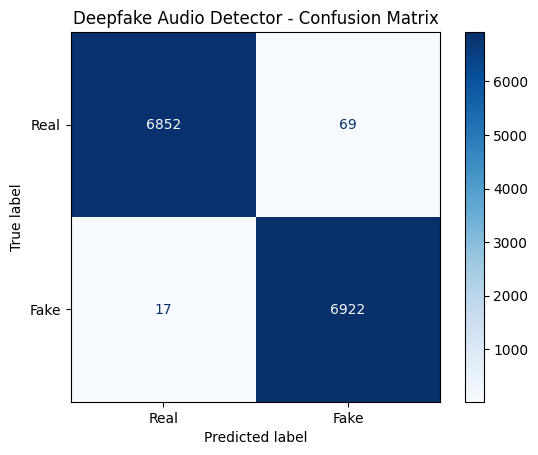

In [40]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Real', 'Fake'])

disp.plot(cmap='Blues')
plt.title('Deepfake Audio Detector - Confusion Matrix')
plt.savefig('confusion_matrix.png')
plt.show()

In [41]:
import pickle

with open('deepfake_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Model saved!")

Model saved!


In [42]:
def predict_audio(file_path):
    features = extract_features(file_path)
    features_scaled = scaler.transform([features])
    prediction = xgb.predict(features_scaled)[0]
    confidence = xgb.predict_proba(features_scaled)[0][prediction] * 100

    if prediction == 1:
        label = "Deepfake (AI Generated)"
    else:
        label = "Genuine (Human)"

    print(f"File: {file_path.split('/')[-1]}")
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.2f}%")
    return label, confidence

# testing on one real and one fake file
print("--- Test 1 ---")
predict_audio(real_test[0])

print("\n--- Test 2 ---")
predict_audio(fake_test[0])

--- Test 1 ---
File: file226.wav_16k.wav_norm.wav_mono.wav_silence.wav
Prediction: Genuine (Human)
Confidence: 99.71%

--- Test 2 ---
File: file226.wav_16k.wav_norm.wav_mono.wav_silence.wav
Prediction: Deepfake (AI Generated)
Confidence: 99.50%


('Deepfake (AI Generated)', np.float32(99.502396))

In [43]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 79.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 117.0 MB/s eta 0:00:00


In [44]:
app_code = '''
import streamlit as st
import librosa
import numpy as np
import pickle

model = pickle.load(open("deepfake_model.pkl", "rb"))
scaler = pickle.load(open("scaler.pkl", "rb"))

def extract_features(file_path, sr=16000, duration=4):
    y, sr = librosa.load(file_path, sr=sr, duration=duration)
    target_length = sr * duration
    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)))
    features = []
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    features.extend(np.mean(mfcc, axis=1))
    features.extend(np.std(mfcc, axis=1))
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    features.extend(np.mean(chroma, axis=1))
    features.append(np.mean(librosa.feature.spectral_centroid(y=y, sr=sr)))
    features.append(np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr)))
    features.append(np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr)))
    features.append(np.mean(librosa.feature.zero_crossing_rate(y)))
    features.append(np.mean(librosa.feature.rms(y=y)))
    return np.array(features)

st.set_page_config(page_title="Deepfake Audio Detector", page_icon="🎙️")

st.title("🎙️ Deepfake Audio Detector")
st.write("Upload an audio file and the model will tell you if it is real or AI generated.")

uploaded = st.file_uploader("Upload Audio", type=["wav", "flac", "mp3"])

if uploaded:
    with open("temp_audio.wav", "wb") as f:
        f.write(uploaded.read())
    st.audio("temp_audio.wav")
    with st.spinner("Analyzing..."):
        feat = extract_features("temp_audio.wav")
        feat_scaled = scaler.transform([feat])
        pred = model.predict(feat_scaled)[0]
        conf = model.predict_proba(feat_scaled)[0][pred] * 100
    if pred == 1:
        st.error(f"🚨 Deepfake Detected! Confidence: {conf:.1f}%")
    else:
        st.success(f"✅ Genuine Human Voice! Confidence: {conf:.1f}%")
'''

with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py created!")

app.py created!


In [45]:
from pyngrok import ngrok
import subprocess
import time

process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port=8501', '--server.headless=true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

public_url = ngrok.connect(8501)
print(f"Your app is live at: {public_url}")

Your app is live at: NgrokTunnel: "https://wad-rundown-squash.ngrok-free.dev" -> "http://localhost:8501"


In [46]:
!ngrok authtoken 3F7LAX1NS1jVV3Tdi2ZdnSkSQP8_5GpVbtzgKtrnuASfTexkQ

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [47]:
!pip install pyngrok -q
from pyngrok import ngrok
ngrok.set_auth_token("3F7LAX1NS1jVV3Tdi2ZdnSkSQP8_5GpVbtzgKtrnuASfTexkQ")
print("ngrok ready!")

ngrok ready!


In [48]:
import subprocess
import time
from pyngrok import ngrok

process = subprocess.Popen(
    ['streamlit', 'run', 'app.py', '--server.port=8501', '--server.headless=true'],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

public_url = ngrok.connect(8501)
print(f"Your app is live at: {public_url}")

Your app is live at: NgrokTunnel: "https://wad-rundown-squash.ngrok-free.dev" -> "http://localhost:8501"


In [49]:
from google.colab import files
files.download(real_test[0])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [50]:
files.download(fake_test[0])

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [51]:
from google.colab import files

files.download('deepfake_model.pkl')
files.download('scaler.pkl')
files.download('app.py')
files.download('confusion_matrix.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>